# Dataset exploration


In [1]:
# imports

from pathlib import Path # handling file paths
import os
import warnings # handling warnings

import numpy as np # linear algebra
import pandas as pd #  CSV files

import matplotlib.pyplot as plt # plotting

warnings.filterwarnings("ignore") # ignore warnings

import zipfile # handling zip files

# view settings for pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 1. Settings
Original dataset downloaded from Kaggle is in zip format. 
The code below extract automatically the file if necessary.

In [2]:
# paths

DATA_DIR = Path("data")   # extraction directory
ZIP_PATH = DATA_DIR / "archive.zip" # path to the zip file
CSV_NAME = "adhdata.csv"  # name of the CSV file inside the zip
CSV_PATH = DATA_DIR / CSV_NAME # path to the extracted CSV file

OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside outputs/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

In [4]:
if not CSV_PATH.exists():
    print("CSV not found. Extracting ZIP file...")

    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"ZIP file not found at {ZIP_PATH}. "
            "Please place archive.zip inside the data/ folder."
        )

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

    print("Extraction completed.")
else:
    print("CSV already extracted.")
    
print("CSV path:", CSV_PATH)
print("CSV exists:", CSV_PATH.exists())

CSV already extracted.
CSV path: data\adhdata.csv
CSV exists: True


## 2. Preview
Let's check the first row of the CSV dataset, EEG signals.

Electroencephalography (EEG) measures electrical activity in the brain using electrodes placed on the scalp. EEG signals provide insights into brain function and are used in various applications, including clinical diagnosis, neuroscience research, and brain-computer interfacing.

In [5]:
df_preview = pd.read_csv(CSV_PATH, nrows=10) # read only the first 10 rows of the CSV file for preview

print("Shape preview:", df_preview.shape) 
display(df_preview.head())

print("\nColumn names:")
print(df_preview.columns.tolist())

print("\nDtypes:") # print the data types of each column in the preview dataframe
display(df_preview.dtypes)

Shape preview: (10, 21)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,200.0,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,16.0,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,-20.0,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,89.0,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,-20.0,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p



Column names:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID']

Dtypes:


Fp1      float64
Fp2      float64
F3       float64
F4       float64
C3       float64
C4       float64
P3       float64
P4       float64
O1       float64
O2       float64
F7       float64
F8       float64
T7       float64
T8       float64
P7       float64
P8       float64
Fz       float64
Cz       float64
Pz       float64
Class     object
ID        object
dtype: object

## 3. EEG channels

Dataset has 19 EEG channels placed following 10-20 system. There are two metadata columns: `Class` e `ID`.

The 10–20 system or International 10–20 system is an internationally recognized method to describe and apply the location of scalp electrodes in the context of an EEG exam. The "10" and "20" refer to the fact that the actual distances between adjacent electrodes are either 10% or 20% of the total front–back or right–left distance of the skull.

Each electrode placement site has a letter to identify the lobe, or area of the brain it is reading from: pre-frontal (Fp), frontal (F), temporal (T), parietal (P), occipital (O), and central (C). There are also (Z) sites: A "Z" (zero) refers to an electrode placed on the midline sagittal plane of the skull, (FpZ, Fz, Cz, Oz) and is present mostly for reference/measurement points.

Even-numbered electrodes (2,4,6,8) refer to electrode placement on the right side of the head and odd numbers (1,3,5,7) refer to those on the left.

In [6]:
# EEG channel definitions following dataset documentation

EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz"
]

META_COLS = ["Class", "ID"]

# check if all expected EEG channels and metadata columns are present in the preview dataframe
missing_channels = [ch for ch in EEG_CHANNELS if ch not in df_preview.columns]
missing_meta = [col for col in META_COLS if col not in df_preview.columns]

print("Missing EEG channels:", missing_channels)
print("Missing metadata columns:", missing_meta)

Missing EEG channels: []
Missing metadata columns: []


## 4. Dataset upload

In [7]:
# full load

dtype_map = {ch: "float32" for ch in EEG_CHANNELS} # set EEG channels to float32
dtype_map.update({"Class": "category", "ID": "category"}) # set Class and ID to category

df = pd.read_csv(CSV_PATH, dtype=dtype_map)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (2166383, 21)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,200.0,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,16.0,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,-20.0,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,89.0,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,-20.0,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


## 5. Checks

In [8]:
# general 
print("Classes:", df["Class"].unique().tolist())
print("Number of rows:", len(df))
print("Number of subjects:", df["ID"].nunique())

print("\nRows per class:")
display(df["Class"].value_counts())

print("\nSubjects per class:")
subjects_per_class = (
    df[["ID", "Class"]]
    .drop_duplicates()
    .groupby("Class")["ID"]
    .nunique()
)
display(subjects_per_class)

print("\nMissing values per column:")
missing = df.isna().sum()
display(missing[missing > 0] if (missing > 0).any() else pd.Series(["No missing values"], name="Missing check"))

print("\nIDs associated with more than one class:")
id_class_counts = df.groupby("ID")["Class"].nunique()
display(id_class_counts[id_class_counts > 1])

Classes: ['ADHD', 'Control']
Number of rows: 2166383
Number of subjects: 121

Rows per class:


Class
ADHD       1207069
Control     959314
Name: count, dtype: int64


Subjects per class:


Class
ADHD       61
Control    60
Name: ID, dtype: int64


Missing values per column:


0    No missing values
Name: Missing check, dtype: object


IDs associated with more than one class:


Series([], Name: Class, dtype: int64)

In [9]:
# subject-level summary

SAMPLING_RATE = 128  # Hz, from dataset documentation
subject_summary = (
    df.groupby(["ID", "Class"], observed=True)
    .size()
    .reset_index(name="n_samples")
)

subject_summary["duration_seconds"] = subject_summary["n_samples"] / SAMPLING_RATE # convert sample count to duration in seconds
subject_summary["duration_minutes"] = subject_summary["duration_seconds"] / 60 # convert duration to minutes

print("Subject-level table shape:", subject_summary.shape)
display(subject_summary.head())

print("\nSummary of estimated duration per subject (minutes):")
display(subject_summary["duration_minutes"].describe()) # display summary statistics for the duration_minutes column in the subject_summary dataframe

Subject-level table shape: (121, 5)


,ID,Class,n_samples,duration_seconds,duration_minutes
0,v10p,ADHD,14304,111.750000,1.862500
1,v12p,ADHD,17604,137.531250,2.292187
2,v14p,ADHD,17562,137.203125,2.286719
3,v15p,ADHD,43252,337.906250,5.631771
4,v173,ADHD,24241,189.382812,3.156380



Summary of estimated duration per subject (minutes):


count    121.000000
mean       2.331249
std        0.808255
min        1.039453
25%        1.783464
50%        2.174089
75%        2.619141
max        5.631771
Name: duration_minutes, dtype: float64

## 6. Visualization

Figure saved to: outputs\figures\0a_class_distribution.png


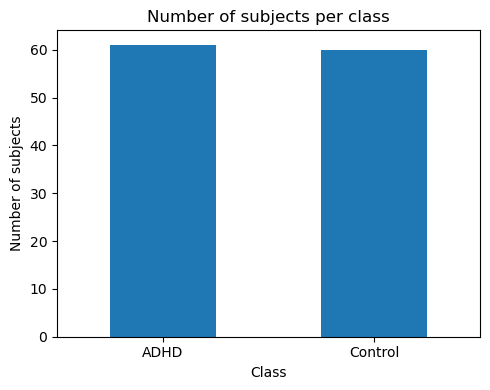

Figure saved to: outputs\figures\0a_recording_distribution.png


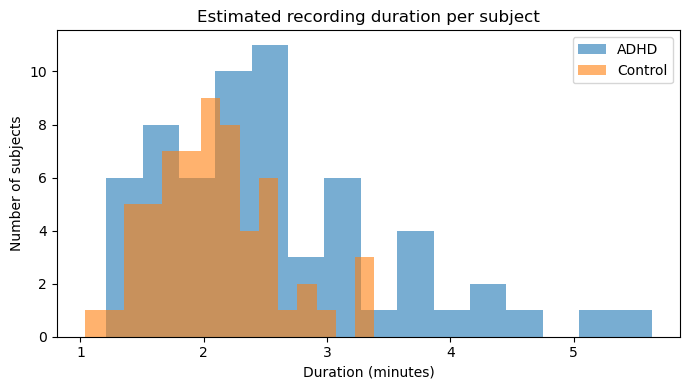

Figure saved to: outputs\figures\0a_recording_distribution_boxplot.png


<Figure size 700x400 with 0 Axes>

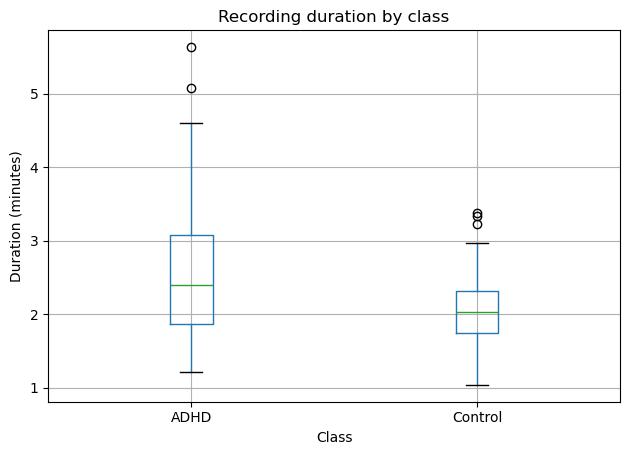

In [10]:
# class balance and duration

plt.figure(figsize=(5, 4))
subject_summary["Class"].value_counts().plot(kind="bar")
plt.title("Number of subjects per class")
plt.xlabel("Class")
plt.ylabel("Number of subjects")
plt.xticks(rotation=0)
save_figure("0a_class_distribution.png")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for cls in subject_summary["Class"].cat.categories:
    vals = subject_summary.loc[subject_summary["Class"] == cls, "duration_minutes"]
    plt.hist(vals, bins=15, alpha=0.6, label=cls)

plt.title("Estimated recording duration per subject")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of subjects")
plt.legend()
save_figure("0a_recording_distribution.png")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
subject_summary.boxplot(column="duration_minutes", by="Class")
plt.title("Recording duration by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Duration (minutes)")
save_figure("0a_recording_distribution_boxplot.png")
plt.tight_layout()
plt.show()

## 7. EEG channels stats

In [11]:
# channel descriptive statistics
channel_stats = df[EEG_CHANNELS].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(channel_stats)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Fp1,2166383.0,136.090302,274.990540,-3786.0,-653.0,-231.0,15.0,121.0,261.0,508.0,965.0,13813.0
Fp2,2166383.0,136.161865,274.519348,-13224.0,-653.0,-231.0,15.0,121.0,226.0,473.0,965.0,4802.0
F3,2166383.0,142.211700,219.976990,-3921.0,-388.0,-167.0,52.0,126.0,236.0,457.0,715.0,5020.0
F4,2166383.0,136.102173,213.238708,-13237.0,-407.0,-160.0,15.0,121.0,226.0,437.0,684.0,4802.0
C3,2166383.0,142.273712,222.803360,-3921.0,-388.0,-167.0,52.0,126.0,236.0,457.0,715.0,5430.0
C4,2166383.0,142.200577,210.005997,-3921.0,-351.0,-131.0,52.0,126.0,236.0,420.0,678.0,5020.0
P3,2166383.0,142.275558,229.566360,-3921.0,-425.0,-167.0,16.0,126.0,236.0,457.0,715.0,5020.0
P4,2166383.0,141.960709,208.979782,-3958.0,-388.0,-131.0,52.0,126.0,236.0,420.0,678.0,5020.0
O1,2166383.0,141.982391,235.346085,-3995.0,-499.0,-167.0,52.0,126.0,236.0,457.0,788.0,5020.0
O2,2166383.0,141.600677,212.712189,-3921.0,-388.0,-131.0,52.0,126.0,236.0,420.0,678.0,5020.0


## 8. Distribuzione dei valori EEG

Visualizziamo la distribuzione dei valori dei canali.  
Per rendere il grafico più leggero, usiamo un campione casuale di righe.

Figure saved to: outputs\figures\0a_channel_amplitude.png


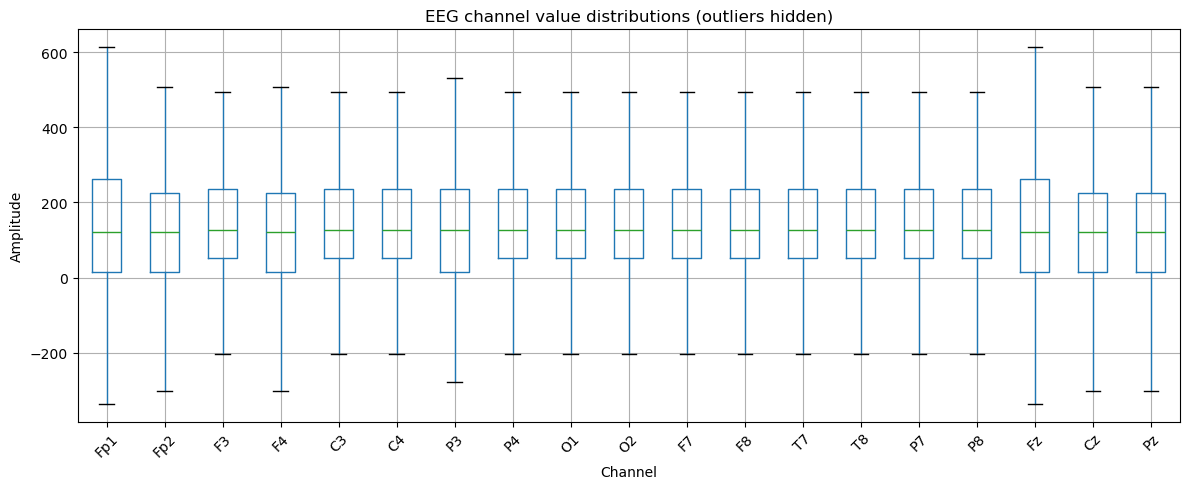

In [12]:
# distribution of EEG values

plt.figure(figsize=(12, 5))
df[EEG_CHANNELS].boxplot(showfliers=False)
plt.title("EEG channel value distributions (outliers hidden)")
plt.xlabel("Channel")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)
save_figure("0a_channel_amplitude.png")
plt.tight_layout()
plt.show()

In [13]:
# region definitions

REGIONS = {
    "frontal": ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"],
    "central": ["C3", "C4", "Cz"],
    "temporal": ["T7", "T8"],
    "parietal": ["P3", "P4", "P7", "P8", "Pz"],
    "occipital": ["O1", "O2"],
}

for region, channels in REGIONS.items():
    print(f"{region}: {channels}")

frontal: ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
central: ['C3', 'C4', 'Cz']
temporal: ['T7', 'T8']
parietal: ['P3', 'P4', 'P7', 'P8', 'Pz']
occipital: ['O1', 'O2']


## 9. EEG signal example

Figure saved to: outputs\figures\0a_ADHD_sample.png


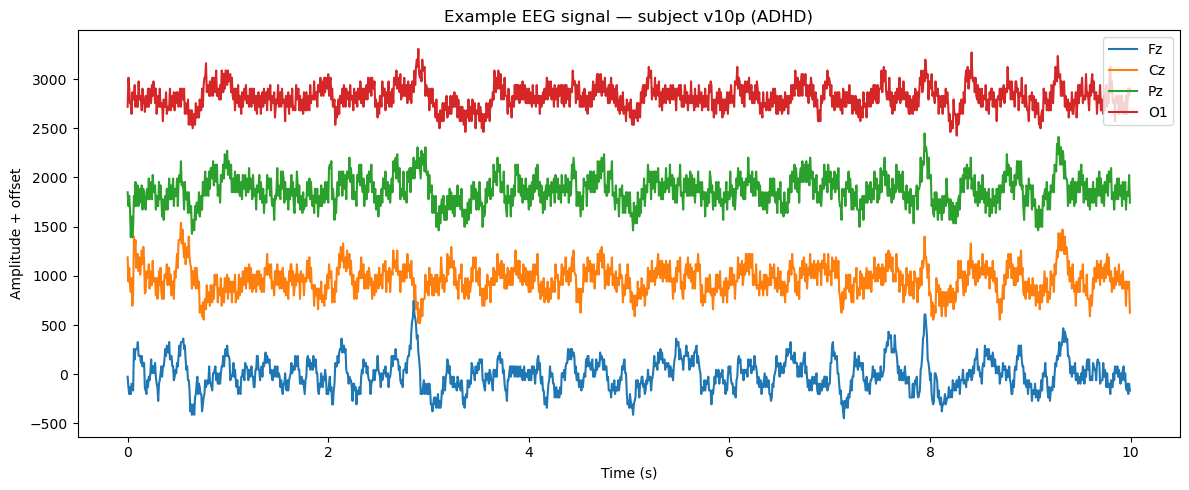

Figure saved to: outputs\figures\0a_Control_sample.png


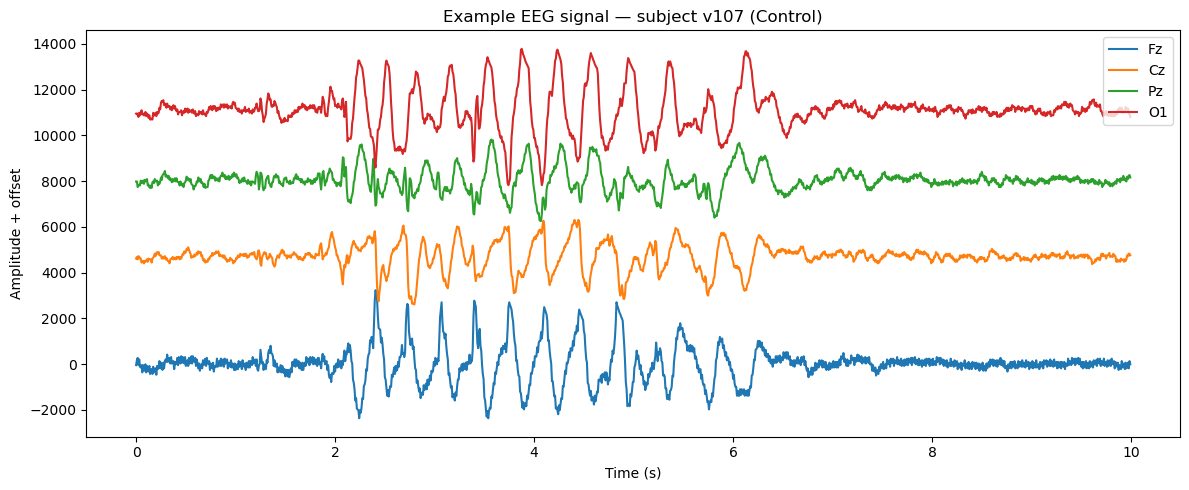

In [14]:
# example signal plot

def plot_subject_signal(df, subject_id, channels=("Fz", "Cz", "Pz", "O1"), seconds=10, fs=128): # plot EEG signals for a given subject and set of channels
    sub = df[df["ID"] == subject_id].copy()
    n = min(len(sub), seconds * fs)
    t = np.arange(n) / fs

    plt.figure(figsize=(12, 5))
    offset = 0

    for ch in channels:
        y = sub[ch].iloc[:n].to_numpy()
        y = y - np.nanmean(y)
        plt.plot(t, y + offset, label=ch)
        offset += np.nanstd(y) * 6 if np.nanstd(y) > 0 else 1

    cls = sub["Class"].iloc[0]
    plt.title(f"Example EEG signal — subject {subject_id} ({cls})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude + offset")
    plt.legend(loc="upper right")
    save_figure(f"0a_{cls}_sample.png")
    plt.tight_layout()
    plt.show()

# plot example signals for one subject from each class
adhd_id = subject_summary.loc[subject_summary["Class"] == "ADHD", "ID"].iloc[0] # iloc[0] to get the first ID from the class
control_id = subject_summary.loc[subject_summary["Class"] == "Control", "ID"].iloc[0]

plot_subject_signal(df, adhd_id)
plot_subject_signal(df, control_id)

## 10. Check on subjects variability 

,ID,Class,mean_channel_std,max_abs_value,n_samples,duration_minutes
0,v10p,ADHD,161.349304,4802.0,14304,1.862500
1,v12p,ADHD,270.278839,2891.0,17604,2.292187
2,v14p,ADHD,287.741791,3711.0,17562,2.286719
3,v15p,ADHD,199.914764,4248.0,43252,5.631771
4,v173,ADHD,125.204681,2260.0,24241,3.156380


,mean_channel_std,max_abs_value,duration_minutes
count,121.000000,121.000000,121.000000
mean,206.163040,3725.165289,2.331249
std,72.146912,1697.760404,0.808255
min,108.232895,1193.000000,1.039453
25%,157.099899,2780.000000,1.783464
50%,190.778183,3732.000000,2.174089
75%,241.494400,4689.000000,2.619141
max,524.940918,13813.000000,5.631771


<Figure size 700x400 with 0 Axes>

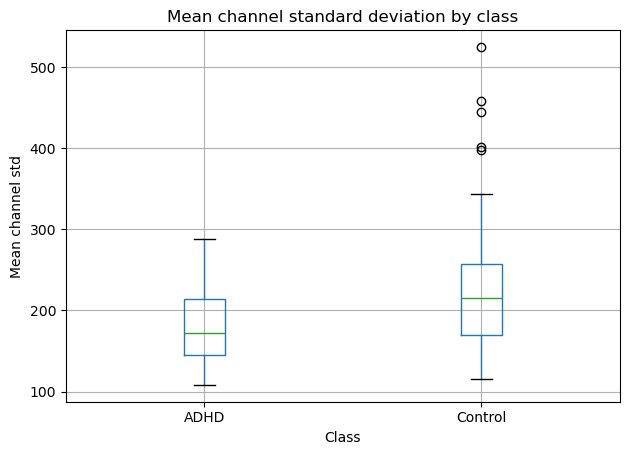

<Figure size 700x400 with 0 Axes>

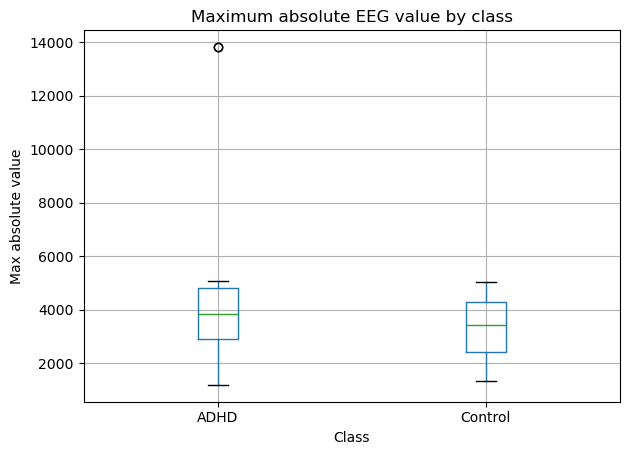

In [15]:
# subject-level signal variability
subject_variability = []

for sid, g in df.groupby("ID", observed=True): # group the dataframe by subject ID and iterate over each group
    cls = g["Class"].iloc[0]
    mean_std = g[EEG_CHANNELS].std().mean()
    max_abs = g[EEG_CHANNELS].abs().max().max()
    subject_variability.append({
        "ID": sid,
        "Class": cls,
        "mean_channel_std": mean_std,
        "max_abs_value": max_abs,
        "n_samples": len(g),
        "duration_minutes": len(g) / SAMPLING_RATE / 60
    })

subject_variability = pd.DataFrame(subject_variability)

display(subject_variability.head())
display(subject_variability[["mean_channel_std", "max_abs_value", "duration_minutes"]].describe())

plt.figure(figsize=(7, 4))
subject_variability.boxplot(column="mean_channel_std", by="Class")
plt.title("Mean channel standard deviation by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Mean channel std")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
subject_variability.boxplot(column="max_abs_value", by="Class")
plt.title("Maximum absolute EEG value by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Max absolute value")
plt.tight_layout()
plt.show()

# subject_variability.to_csv(OUTPUT_DIR / "subject_variability.csv", index=False)
# print("Saved:", OUTPUT_DIR / "subject_variability.csv")

In [16]:

# Compact dataset summary

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total subjects",
        "ADHD subjects",
        "Control subjects",
        "Sampling rate (Hz)",
        "Number of EEG channels",
        "Median duration per subject (min)",
        "Min duration per subject (min)",
        "Max duration per subject (min)"
    ],
    "Value": [
        len(df),
        subject_summary["ID"].nunique(),
        int((subject_summary["Class"] == "ADHD").sum()),
        int((subject_summary["Class"] == "Control").sum()),
        SAMPLING_RATE,
        len(EEG_CHANNELS),
        round(subject_summary["duration_minutes"].median(), 2),
        round(subject_summary["duration_minutes"].min(), 2),
        round(subject_summary["duration_minutes"].max(), 2),
    ]
})

display(dataset_summary)
# dataset_summary.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
# print("Saved:", OUTPUT_DIR / "dataset_summary.csv")

,Metric,Value
0,Total rows,2166383.00
1,Total subjects,121.00
2,ADHD subjects,61.00
3,Control subjects,60.00
4,Sampling rate (Hz),128.00
5,Number of EEG channels,19.00
6,Median duration per subject (min),2.17
7,Min duration per subject (min),1.04
8,Max duration per subject (min),5.63
